# Getting started with nSTAT-python

This is the **executable entry-point notebook**. It mirrors the [5-minute intro](https://cajigaslab.github.io/nSTAT-python/intro.html) on the docs site, but runs end-to-end in your kernel: every cell produces output you can inspect.

**What you'll do in ~5 minutes:**
1. Build a spike train (`nspikeTrain`)
2. Group spike trains into a population (`nstColl`)
3. Simulate a stimulus-driven neuron, then fit a point-process GLM (`fit_poisson_glm`)
4. Check the fit with the time-rescaling KS test (`population_time_rescale`)
5. Decode the stimulus back from a population (`DecodingAlgorithms.PPDecodeFilterLinear`)

**Prerequisites:** `pip install nstat-toolbox`. No example dataset is required — every cell uses simulated data. No optional extras (Dynamax, replay_trajectory_classification) are needed; this notebook stays in the core API.

**Where to go next:** the [Concepts & Background](https://cajigaslab.github.io/nSTAT-python/concepts/index.html) pages teach the theory, the [`examples/tutorials/`](https://github.com/cajigaslab/nSTAT-python/tree/main/examples/tutorials) scripts walk through each idea end-to-end, and the [paper examples](https://cajigaslab.github.io/nSTAT-python/paper_examples.html) reproduce the 2012 paper's analyses.

In [ ]:
# If running this notebook from the repo source tree (not pip-installed),
# make sure `nstat` is importable. No-op if `pip install nstat-toolbox` was used.
import sys
from pathlib import Path
_REPO = Path.cwd().resolve()
if (_REPO / "nstat" / "__init__.py").exists() and str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))
elif (_REPO.parent / "nstat" / "__init__.py").exists() and str(_REPO.parent) not in sys.path:
    sys.path.insert(0, str(_REPO.parent))

import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_figures import matlab_raster

rng = np.random.default_rng(0)  # one seed for the whole notebook

## 1. Build a spike train

`nspikeTrain` wraps a vector of spike times into the universal spike-train object used everywhere in the toolbox. The name preserves the MATLAB original's lowercase `n`.

In [ ]:
from nstat import nspikeTrain

times = np.sort(rng.uniform(0, 1, 100))
st = nspikeTrain(times, name="neuron1", sampleRate=1000,
                 minTime=0.0, maxTime=1.0)
print(f"{st.n_spikes} spikes over {st.maxTime - st.minTime:.2f} s")
print(f"mean rate ≈ {st.n_spikes / (st.maxTime - st.minTime):.0f} Hz")

fig, ax = plt.subplots(figsize=(7, 1.4))
matlab_raster(ax, st.spikeTimes, row=0.5, half_height=0.5)
ax.set_xlabel("time (s)"); ax.set_yticks([]); ax.set_title("neuron1 raster")
plt.tight_layout(); plt.show()

## 2. Group spike trains into a population

`nstColl` (a.k.a. `SpikeTrainCollection`) is the ensemble container. Once you have a population, peri-stimulus time histograms, ensemble GLM terms, and population goodness-of-fit are all one call away.

population: 8 units, 780 spikes total


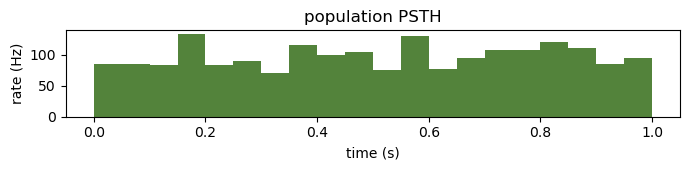

In [3]:
from nstat import nstColl, psth

trains = [
    nspikeTrain(np.sort(rng.uniform(0, 1, 80 + i * 5)),
                name=f"neuron{i+1}", sampleRate=1000,
                minTime=0.0, maxTime=1.0)
    for i in range(8)
]
pop = nstColl(trains)
pop.setMinTime(0.0); pop.setMaxTime(1.0)
print(f"population: {pop.numSpikeTrains} units, "
      f"{sum(t.n_spikes for t in pop.nstrain)} spikes total")

edges = np.arange(0.0, 1.0 + 0.05, 0.05)
mean_rate, _ = psth(trains, edges)
fig, ax = plt.subplots(figsize=(7, 1.8))
ax.bar(edges[:-1], mean_rate, width=np.diff(edges), align="edge",
       color="#356d18", alpha=0.85)
ax.set_xlabel("time (s)"); ax.set_ylabel("rate (Hz)")
ax.set_title("population PSTH")
plt.tight_layout(); plt.show()

## 3. Fit a point-process GLM

Now simulate a neuron with *known* tuning to a sinusoidal stimulus, then recover that tuning by fitting a Poisson GLM. The log-likelihood is concave ([Paninski 2004](https://pubmed.ncbi.nlm.nih.gov/15600233/)), so the fit converges to a unique maximum.

In [4]:
from nstat import fit_poisson_glm, simulate_cif_from_stimulus

# truth: 1 Hz sinusoid drives a neuron with baseline ~5 Hz and slope 1.2
# (so rate sweeps between exp(1.6-1.2) ≈ 1.6 Hz and exp(1.6+1.2) ≈ 16 Hz)
true_beta0, true_beta1 = 1.6, 1.2
t = np.arange(0.0, 60.0, 1e-3)
stim = np.sin(2 * np.pi * 1.0 * t)
spikes, rate_hz, _ = simulate_cif_from_stimulus(
    time=t, stimulus=stim, beta0=true_beta0, beta1=true_beta1, rng=rng
)
print(f"simulated {spikes.n_spikes} spikes "
      f"(mean rate ≈ {rate_hz.mean():.1f} Hz)")

# Bin to 10 ms and fit a Poisson GLM with log(bin_width) offset.
bin_width = 0.01
edges = np.arange(0.0, 60.0 + bin_width, bin_width)
y = spikes.to_binned_counts(edges)
samples_per_bin = int(round(bin_width / (t[1] - t[0])))
x = stim.reshape(-1, samples_per_bin).mean(axis=1)[:, None]
offset = np.full(y.shape, np.log(bin_width))
fit = fit_poisson_glm(x, y, offset=offset, l2=0.0)

print(f"\ntrue intercept = {true_beta0:+.2f}   estimated = {fit.intercept:+.3f}")
print(f"true slope     = {true_beta1:+.2f}   estimated = {fit.coefficients[0]:+.3f}")
print(f"converged in {fit.n_iter} iters; log-LL = {fit.log_likelihood:.1f}")

simulated 391 spikes (mean rate ≈ 6.9 Hz)

true intercept = +1.60   estimated = +1.530
true slope     = +1.20   estimated = +1.223
converged in 15 iters; log-LL = -1344.6


## 4. Check the fit — time-rescaling KS test

A low AIC means a model fits *better than another model*. The **time-rescaling theorem** ([Brown et al. 2002](https://pubmed.ncbi.nlm.nih.gov/11802915/)) gives an *absolute* check: if the conditional intensity is correct, the rescaled inter-spike intervals are uniform. The marked extension ([Tao et al. 2018](https://pubmed.ncbi.nlm.nih.gov/30298220/)) scores a whole population jointly and catches coupling misfit.

Here we contrast the correct (stimulus-aware) model against a deliberately wrong (constant-rate) model:

In [5]:
from nstat import population_time_rescale

# Compute per-bin expected counts under (a) the fitted stimulus-aware model
# and (b) a deliberately wrong constant-rate model with the same mean rate.
lam_correct  = np.exp(fit.intercept + fit.coefficients[0] * x[:, 0]) * bin_width
lam_constant = np.full_like(lam_correct, y.mean())

gof_correct  = population_time_rescale([y], [lam_correct])
gof_constant = population_time_rescale([y], [lam_constant])

print(f"correct  model: ground-process KS p = {gof_correct.ground_ks_pvalue:.3g}")
print(f"constant model: ground-process KS p = {gof_constant.ground_ks_pvalue:.3g}")
print("\nThe constant model matches the *mean rate* but not the timing —")
print("only the stimulus-aware model passes the KS test.")

correct  model: ground-process KS p = 0.268
constant model: ground-process KS p = 3.7e-07

The constant model matches the *mean rate* but not the timing —
only the stimulus-aware model passes the KS test.


## 5. Decode the stimulus from a population

Encoding asks "what drives this neuron?" Decoding asks the inverse: given the spikes, what was the stimulus? Here we simulate a small population (each neuron with random tuning), then reconstruct the hidden stimulus with the **point-process adaptive filter (PPAF)** ([Eden et al. 2004](https://pubmed.ncbi.nlm.nih.gov/15070506/)) — the spiking analogue of the Kalman filter.

(This cell uses only the core API. The optional [clusterless bridge](https://cajigaslab.github.io/nSTAT-python/extras/decoding_clusterless.html) handles unsorted spikes if your data needs it.)

simulated 2064 spikes across 25 cells
decode RMSE = 0.132 (stimulus std = 0.849)


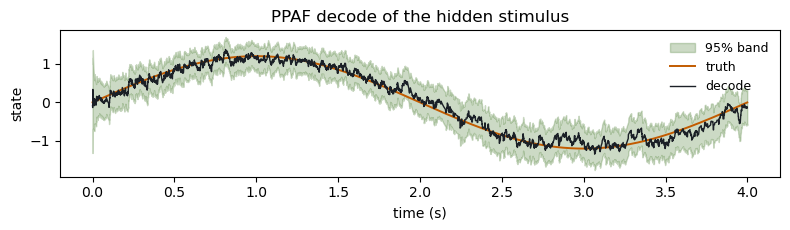

In [6]:
from nstat import DecodingAlgorithms

# 25-cell population, each tuned to a slow stimulus.
# Same generative setup as examples/tutorials/decoding_ppaf.py:
# logistic CIF (Bernoulli per bin), so we decode with fitType="binomial".
dt = 0.001
T = np.arange(0.0, 4.0, dt)
stim_true = 1.2 * np.sin(2 * np.pi * 0.25 * T)
n_cells = 25
b1 = rng.standard_normal(n_cells)                                   # tuning slope
b0 = np.log(10.0 * dt) + rng.standard_normal(n_cells)               # baseline log-odds

counts = np.zeros((n_cells, T.size), dtype=float)
for c in range(n_cells):
    eta = np.clip(b0[c] + b1[c] * stim_true, -20.0, 20.0)
    p = np.exp(eta) / (1.0 + np.exp(eta))
    counts[c] = (rng.random(T.size) < p).astype(float)
print(f"simulated {int(counts.sum())} spikes across {n_cells} cells")

# PPDecodeFilterLinear: A/Q describe a random-walk prior on the state;
# mu (b0) and beta (b1) describe each cell's logistic CIF. The filter
# returns predicted + updated states with their covariances (8 outputs;
# we keep the updated state x_u and W_u).
A   = np.array([[1.0]])                                    # state dynamics
Q   = np.array([[float(np.std(np.diff(stim_true)))]])      # process noise ~ stim wiggle
x0  = np.array([0.0])
Pi0 = 0.5 * np.eye(1)
beta = b1.reshape(1, -1)                                   # (1 state, n_cells)

_, _, x_u, W_u, *_ = DecodingAlgorithms.PPDecodeFilterLinear(
    A, Q, counts, b0, beta, "binomial", dt, None, None, x0, Pi0
)
x_hat = x_u[0, :]
sd    = np.sqrt(np.maximum(W_u[0, 0, :], 0.0))
rmse  = float(np.sqrt(np.mean((x_hat - stim_true) ** 2)))
print(f"decode RMSE = {rmse:.3f} (stimulus std = {stim_true.std():.3f})")

fig, ax = plt.subplots(figsize=(8, 2.4))
ax.fill_between(T, x_hat - 1.96*sd, x_hat + 1.96*sd,
                color="#356d18", alpha=0.25, label="95% band")
ax.plot(T, stim_true, color="#c25b00", lw=1.4, label="truth")
ax.plot(T, x_hat,     color="#1b2027", lw=1.0, label="decode")
ax.set_xlabel("time (s)"); ax.set_ylabel("state")
ax.set_title("PPAF decode of the hidden stimulus")
ax.legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

## Where to go next

You've now touched every part of the core workflow. Concrete next steps, in order of depth:

- **Read the [concepts pages](https://cajigaslab.github.io/nSTAT-python/concepts/index.html)** to understand the theory — microelectrode recordings, point-process GLMs, time-rescaling, decoding, state-space EM, and rhythmic firing.
- **Run the [tutorial scripts](https://github.com/cajigaslab/nSTAT-python/tree/main/examples/tutorials)** for end-to-end lessons on each concept (encoding→GOF, decoding, model comparison, network coupling, clinical microelectrode, place-cell capstone).
- **Reproduce the [paper examples](https://cajigaslab.github.io/nSTAT-python/paper_examples.html)** (Cajigas, Malik & Brown 2012) on the figshare dataset — each is a self-contained Python script with a generated figure gallery.
- **Browse the [API reference](https://cajigaslab.github.io/nSTAT-python/api.html)** and [class catalog](https://cajigaslab.github.io/nSTAT-python/ClassDefinitions.html) for the full surface.
- **Opt-in extras**: state-space EM (Dynamax), clusterless decoding, validation oracles (NeMoS / pykalman / statsmodels), data interop (Neo / pynapple / pynwb) — see the [extras summary](https://cajigaslab.github.io/nSTAT-python/extras_summary.html).